# Campaign group analysis

Load the saved Step 3 graph, IO labels, classifier predictions, and node indicators for one campaign. Then build and aggregate the five graph-based account groups.

In [69]:
from pathlib import Path

import networkx as nx
import pandas as pd

## Parameters

In [70]:
campaign_name = "Armenia"

## Locate the saved Step 3 files

This analysis uses the standard Step 3 output with `BERTopic_topic_256` and a top percentage of 100.

In [71]:
def find_project_root(start_path: str | Path) -> Path:
    """Find the project root containing the src and results folders.

    Args:
        start_path: Directory from which to search upward.

    Returns:
        Project root directory.

    Raises:
        FileNotFoundError: If the project root cannot be found.
    """
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "src").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")


project_root = find_project_root(Path.cwd())
topic_col = "BERTopic_topic_256"
top_percentage = 100
dataset_part = f"{campaign_name}_part_all"
step_3_path = (
    project_root
    / "results"
    / "Labeled_Datasets"
    / campaign_name
    / dataset_part
    / "step_3_key_authors_graph"
    / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
)
graph_stem = f"accounts_graph_topic_col_{topic_col}"
graph_path = step_3_path / f"{graph_stem}.graphml"
node_indicators_path = step_3_path / f"{graph_stem}_node_indicators.parquet"
data_path = step_3_path / f"{dataset_part}_step_3.gzip.parquet"
classifier_predictions_path = (
    step_3_path
    / "io_classification_random_forest_all_indicators_cv_predictions.csv"
)

input_paths = {
    "graph": graph_path,
    "node indicators": node_indicators_path,
    "post data": data_path,
    "classifier predictions": classifier_predictions_path,
}
missing_paths = [path for path in input_paths.values() if not path.is_file()]
if missing_paths:
    missing_text = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Missing Step 3 input files:\n{missing_text}")

pd.DataFrame.from_dict(input_paths, orient="index", columns=["path"])

,path
graph,/home/amitner/Backbone-Graph/results/Labeled_D...
node indicators,/home/amitner/Backbone-Graph/results/Labeled_D...
post data,/home/amitner/Backbone-Graph/results/Labeled_D...
classifier predictions,/home/amitner/Backbone-Graph/results/Labeled_D...


In [ ]:
# analysis_output_path = project_root / "result" / "group_analysis" / campaign_name
group_analysis_folder_path = step_3_path / "group_analysis"

## Import the group-analysis functions

Definition-only mode imports the functions without running the Step 3 demonstrations or rebuilding data.

In [73]:
starting_directory = Path.cwd()
%cd {project_root / "src"}
key_authors_graph_definition_only = True
%run -i 3_key_authors_graph.ipynb
%cd {starting_directory}

/home/amitner/Backbone-Graph/src
env: NX_CUGRAPH_AUTOCONFIG=False
Project root: /home/amitner/Backbone-Graph
Input data path: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador_Test/Ecuador_Test_part_all/step_2_BERTopic_clustering/Ecuador_Test_part_all_step_2.gzip.parquet
/home/amitner/Backbone-Graph/src/temp


## Load the graph, labels, predictions, and indicators

In [74]:
G_accounts = nx.read_graphml(graph_path)
node_indicators_df = pd.read_parquet(node_indicators_path)
node_indicators_df.index = node_indicators_df.index.astype(str)
df = pd.read_parquet(
    data_path,
    columns=["accountid", "post_time", topic_col, f"{topic_col}_top_words"],
)

classifier_predictions_df = pd.read_csv(
    classifier_predictions_path,
    dtype={"author_id": str},
)
io_authors_set = set(
    classifier_predictions_df.loc[
        classifier_predictions_df["is_io"].eq(1),
        "author_id",
    ]
)
classifier_io_authors_set = set(
    classifier_predictions_df.loc[
        classifier_predictions_df["predicted_is_io"].eq(1),
        "author_id",
    ]
)

load_summary_df = pd.DataFrame(
    {
        "value": [
            G_accounts.number_of_nodes(),
            G_accounts.number_of_edges(),
            len(node_indicators_df),
            len(io_authors_set),
            len(classifier_io_authors_set),
        ]
    },
    index=[
        "graph nodes",
        "graph edges",
        "node indicator rows",
        "ground-truth IO authors",
        "classifier-predicted IO authors",
    ],
)
load_summary_df.style.format({"value": "{:,}"})

,value
graph nodes,"1,798"
graph edges,"20,100"
node indicator rows,"1,798"
ground-truth IO authors,31
classifier-predicted IO authors,19


## Group analysis

### All Authors

In [ ]:
all_node_group_analysis_df = build_group_analysis(
    nodes=set(G_accounts.nodes),
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_set=classifier_io_authors_set,
    node_indicators_df=node_indicators_df,
    output_path = group_analysis_folder_path,
    output_filename="all_nodes_group_analysis_results.csv",
)

group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=all_node_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="all_nodes",
)

2026-08-17 17:43:17 | job_id=20250137 | Starting build_group_analysis: requested_accounts=1,798, graph_nodes=1,798, classifier_io_accounts=19 | memory_used=12.29 GiB | max_memory=12.89 GiB
2026-08-17 17:43:17 | job_id=20250137 | [build_group_analysis] Resolving topic and community attributes | memory_used=12.29 GiB | max_memory=12.89 GiB
2026-08-17 17:43:17 | job_id=20250137 | [build_group_analysis] Building requested topic and community groups | memory_used=12.29 GiB | max_memory=12.89 GiB
2026-08-17 17:43:17 | job_id=20250137 | [build_group_analysis] Computing core numbers | memory_used=12.29 GiB | max_memory=12.89 GiB


Finding requested k-core groups: 100%|██████████| 37/37 [00:00<00:00, 1022.66core/s]


2026-08-17 17:43:18 | job_id=20250137 | [build_group_analysis] Calculating five groups for 1,798 accounts | memory_used=12.29 GiB | max_memory=12.89 GiB


Calculating account groups: 100%|██████████| 1798/1798 [00:00<00:00, 6516.63account/s]


2026-08-17 17:43:18 | job_id=20250137 | Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Armenia/Armenia_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/group_analysis_results.csv | memory_used=12.29 GiB | max_memory=12.89 GiB


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,0003b99a95f8f7dd7e452000529b4071b560eece0e,maximal_k_core_component,core=18|component=0003b99a95f8f7dd7e452000529b...,20,0.000000,65.000000
1,0003b99a95f8f7dd7e452000529b4071b560eece0e,direct_neighbors,account=0003b99a95f8f7dd7e452000529b4071b560ee...,31,3.225806,64.516129
2,0003b99a95f8f7dd7e452000529b4071b560eece0e,louvain_community,community=32,62,0.000000,64.516129
3,0003b99a95f8f7dd7e452000529b4071b560eece0e,same_top_topic,topic=0,1048,1.622137,100.000000
4,0003b99a95f8f7dd7e452000529b4071b560eece0e,classifier_predicted_io,classifier_io,19,94.736842,47.368421


2026-08-17 17:43:18 | job_id=20250137 | Completed: build_group_analysis | memory_used=12.29 GiB | max_memory=12.89 GiB


### Io Authors

In [ ]:
rf_io_authors_group_analysis_df = build_group_analysis(
    nodes=set(classifier_io_authors_set),
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_set=classifier_io_authors_set,
    node_indicators_df=node_indicators_df,
    output_path = group_analysis_folder_path,
    output_filename="rf_io_authors_group_analysis_results.csv",
)

rf_io_authors_group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=rf_io_authors_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="rf_io_authors",
)

2026-08-17 17:27:19 | job_id=20250137 | Starting build_group_analysis: requested_accounts=602, graph_nodes=5,675, classifier_io_accounts=602 | memory_used=12.45 GiB | max_memory=12.70 GiB
2026-08-17 17:27:19 | job_id=20250137 | [build_group_analysis] Resolving topic and community attributes | memory_used=12.45 GiB | max_memory=12.70 GiB
2026-08-17 17:27:19 | job_id=20250137 | [build_group_analysis] Building requested topic and community groups | memory_used=12.45 GiB | max_memory=12.70 GiB
2026-08-17 17:27:19 | job_id=20250137 | [build_group_analysis] Computing core numbers | memory_used=12.45 GiB | max_memory=12.70 GiB


Finding requested k-core groups: 100%|██████████| 99/99 [00:00<00:00, 609.06core/s]


2026-08-17 17:27:20 | job_id=20250137 | [build_group_analysis] Calculating five groups for 602 accounts | memory_used=12.45 GiB | max_memory=12.70 GiB


Calculating account groups: 100%|██████████| 602/602 [00:00<00:00, 1948.60account/s]

2026-08-17 17:27:20 | job_id=20250137 | Saved group analysis results to: /home/amitner/Backbone-Graph/result/group_analysis/Iran_1/group_analysis_results.csv | memory_used=12.44 GiB | max_memory=12.70 GiB


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,00743ec585f4839f024221d1762985d2559f046eb7,maximal_k_core_component,core=124|component=00743ec585f4839f024221d1762...,312,100.000000,32.051282
1,00743ec585f4839f024221d1762985d2559f046eb7,direct_neighbors,account=00743ec585f4839f024221d1762985d2559f04...,167,100.000000,63.473054
2,00743ec585f4839f024221d1762985d2559f046eb7,louvain_community,community=123,203,100.000000,57.635468
3,00743ec585f4839f024221d1762985d2559f046eb7,same_top_topic,topic=6,374,44.117647,100.000000
4,00743ec585f4839f024221d1762985d2559f046eb7,classifier_predicted_io,classifier_io,602,97.508306,26.411960


2026-08-17 17:27:20 | job_id=20250137 | Completed: build_group_analysis | memory_used=12.44 GiB | max_memory=12.70 GiB


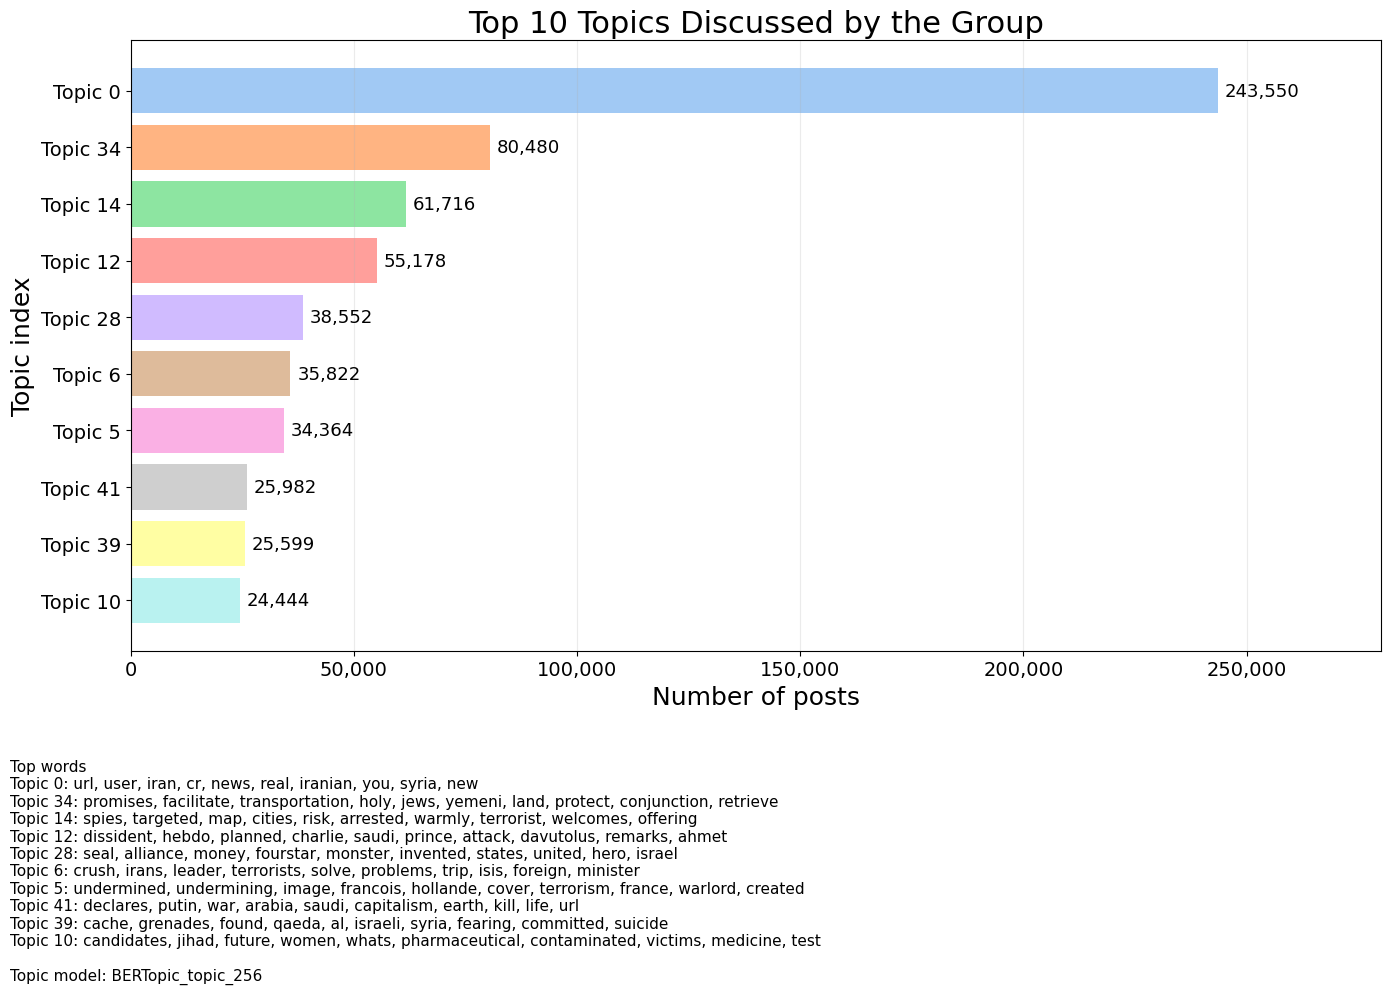

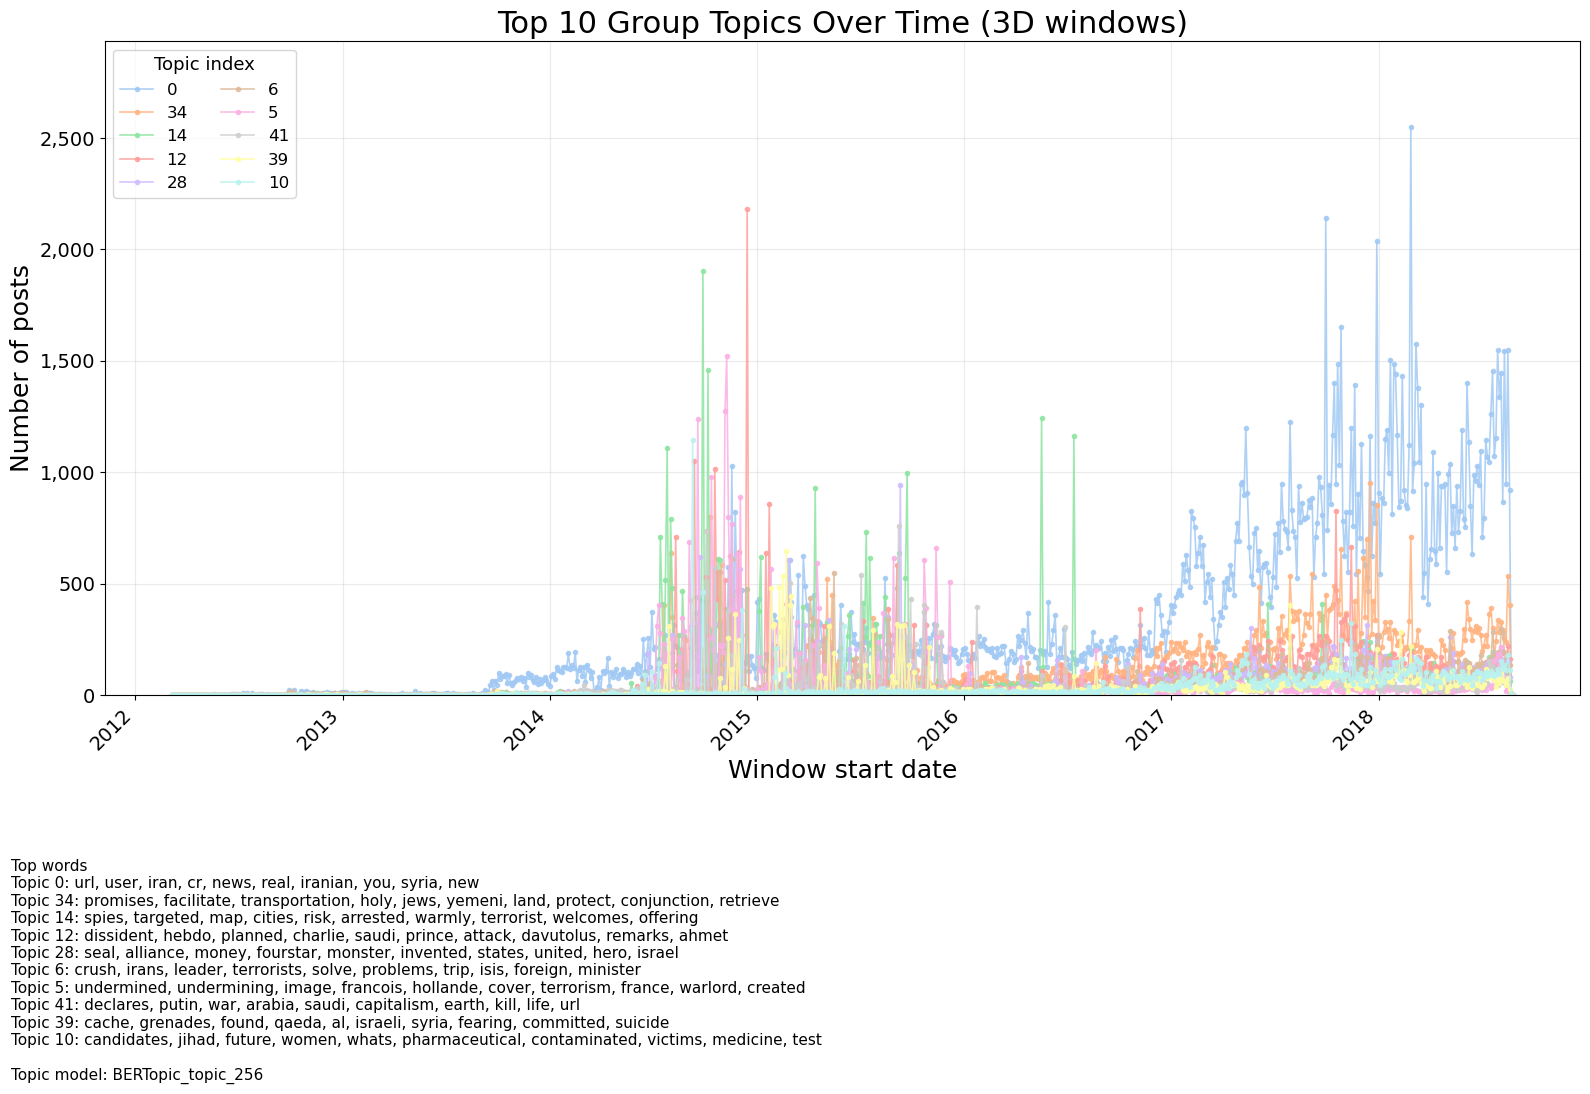

Saved temporal topic counts to: /home/amitner/Backbone-Graph/result/group_analysis/Iran_1/classifier_io_group_topics/group_topic_counts_BERTopic_topic_256_3D.csv
Saved topic distribution plot to: /home/amitner/Backbone-Graph/result/group_analysis/Iran_1/classifier_io_group_topics/group_topic_distribution_BERTopic_topic_256.png
Saved temporal topic plot to: /home/amitner/Backbone-Graph/result/group_analysis/Iran_1/classifier_io_group_topics/group_topics_over_time_BERTopic_topic_256_3D.png


,start_date,end_date,BERTopic_topic_256,post_count,topic_top_words
0,2012-03-06,2012-03-09,17,1,"url, title, umut, later, 40, months, whats, day"
1,2012-03-12,2012-03-15,0,2,"url, user, iran, cr, news, real, iranian, you,..."
2,2012-04-17,2012-04-20,0,2,"url, user, iran, cr, news, real, iranian, you,..."
3,2012-04-17,2012-04-20,86,1,"comments, deschamps, ibrahimovic, zlatan, biza..."
4,2012-04-29,2012-05-02,17,5,"url, title, umut, later, 40, months, whats, day"
5,2012-04-29,2012-05-02,0,2,"url, user, iran, cr, news, real, iranian, you,..."
6,2012-04-29,2012-05-02,28,1,"seal, alliance, money, fourstar, monster, inve..."
7,2012-05-05,2012-05-08,0,3,"url, user, iran, cr, news, real, iranian, you,..."
8,2012-05-05,2012-05-08,17,1,"url, title, umut, later, 40, months, whats, day"
9,2012-05-08,2012-05-11,0,2,"url, user, iran, cr, news, real, iranian, you,..."


2026-08-17 17:27:35 | job_id=20250137 | Completed: analyze_group_topics | memory_used=12.45 GiB | max_memory=12.70 GiB


In [ ]:
group_topic_counts_df = analyze_group_topics(
    df=df,
    nodes=classifier_io_authors_set,
    time_window="3D",
    topic_col=topic_col,
    output_path=analysis_output_path / "classifier_io_group_topics",
)